In [1]:
!pip install prophet scikit-learn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("✓ All libraries loaded.")

✓ All libraries loaded.


In [7]:
# ================================================================
# Synthetic FMCG Demand & RGM Analytics — Brookside Dairy Kenya
# Categories: Fresh Milk, Fermented, Cheese & Butter, Juices
# 3 years | 12 SKUs | 5 channels | East African market context
# Note: Synthetic data generated for portfolio demonstration
# ================================================================

np.random.seed(42)

skus = {
    'Fresh Milk':        ['Brookside Full Cream 500ml', 'Brookside Full Cream 1L',
                          'Brookside Skimmed 1L',       'Eldoville Fresh Milk 500ml'],
    'Fermented':         ['Brookside Yoghurt Plain 500g', 'Brookside Yoghurt Strawberry 500g',
                          'Mala Cultured Milk 500ml',     'Fresha Yoghurt Drinking 250ml'],
    'Cheese & Butter':   ['Brookside Butter 250g', 'Tuzo Cheddar Cheese 200g'],
    'Juices':            ['Chillys Mango Juice 500ml', 'Chillys Orange Juice 1L']
}

channels = ['Supermarkets', 'General Trade', 'Wholesale', 'Convenience', 'Institutions']
dates    = pd.date_range('2022-01-01', '2024-12-31', freq='W-MON')

rows = []
for category, sku_list in skus.items():
    for sku in sku_list:
        base_price = np.random.uniform(55, 480)
        base_vol   = np.random.randint(400, 2000)

        for channel in channels:
            channel_factor = {
                'Supermarkets': 1.4, 'General Trade': 1.2,
                'Wholesale':    1.8, 'Convenience':   0.7,
                'Institutions': 1.1
            }[channel]

            for date in dates:
                month = date.month

                # Kenya dairy seasonality:
                # Peak: Dec-Jan (festive), Apr (Easter), Aug (back to school)
                # Dip: Feb-Mar (post-festive), Jun (mid-year)
                season_idx = (
                    1.0
                    + 0.30 * (1 if month in [12, 1] else 0)   # festive peak
                    + 0.15 * (1 if month in [4]     else 0)   # Easter
                    + 0.10 * (1 if month in [8]     else 0)   # back to school
                    - 0.10 * (1 if month in [2, 3]  else 0)   # post-festive dip
                    - 0.08 * (1 if month in [6]     else 0)   # mid-year dip
                )

                # Promotions — 20% of weeks, stronger in supermarkets
                promo_prob   = 0.28 if channel == 'Supermarkets' else 0.18
                promo        = np.random.choice([0, 1], p=[1 - promo_prob, promo_prob])
                promo_uplift = np.random.uniform(1.20, 1.45) if promo else 1.0
                price        = base_price * (0.88 if promo else 1.0)

                volume       = int(base_vol * channel_factor * season_idx *
                                   promo_uplift * np.random.uniform(0.88, 1.12))
                revenue      = round(volume * price, 0)
                cogs         = round(revenue * np.random.uniform(0.48, 0.62), 0)
                gross_profit = revenue - cogs

                rows.append({
                    'Date':             date,
                    'Category':         category,
                    'SKU':              sku,
                    'Channel':          channel,
                    'Promo':            promo,
                    'Price_KES':        round(price, 2),
                    'Volume_Units':     volume,
                    'Revenue_KES':      revenue,
                    'COGS_KES':         cogs,
                    'Gross_Profit_KES': gross_profit
                })

df = pd.DataFrame(rows)
df['Gross_Margin_%'] = (df['Gross_Profit_KES'] / df['Revenue_KES'] * 100).round(1)
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

print(f"✓ Dataset generated: {len(df):,} records")
print(f"  Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Categories  : {df['Category'].nunique()} | SKUs: {df['SKU'].nunique()}")
print(f"  Channels    : {df['Channel'].nunique()}")
print(f"  Total Revenue : KES {df['Revenue_KES'].sum()/1e9:.2f}B")
print(f"  Avg Gross Margin: {df['Gross_Margin_%'].mean():.1f}%")
df.head(3)

✓ Dataset generated: 9,420 records
  Date range  : 2022-01-03 → 2024-12-30
  Categories  : 4 | SKUs: 12
  Channels    : 5
  Total Revenue : KES 4.58B
  Avg Gross Margin: 45.0%


,Date,Category,SKU,Channel,Promo,Price_KES,Volume_Units,Revenue_KES,COGS_KES,Gross_Profit_KES,Gross_Margin_%,Year,Month,Quarter
0,2022-01-03,Fresh Milk,Brookside Full Cream 500ml,Supermarkets,0,214.18,2447,524097.0,295360.0,228737.0,43.6,2022,1,1
1,2022-01-10,Fresh Milk,Brookside Full Cream 500ml,Supermarkets,0,214.18,2073,443994.0,241664.0,202330.0,45.6,2022,1,1
2,2022-01-17,Fresh Milk,Brookside Full Cream 500ml,Supermarkets,0,214.18,2096,448920.0,256389.0,192531.0,42.9,2022,1,1


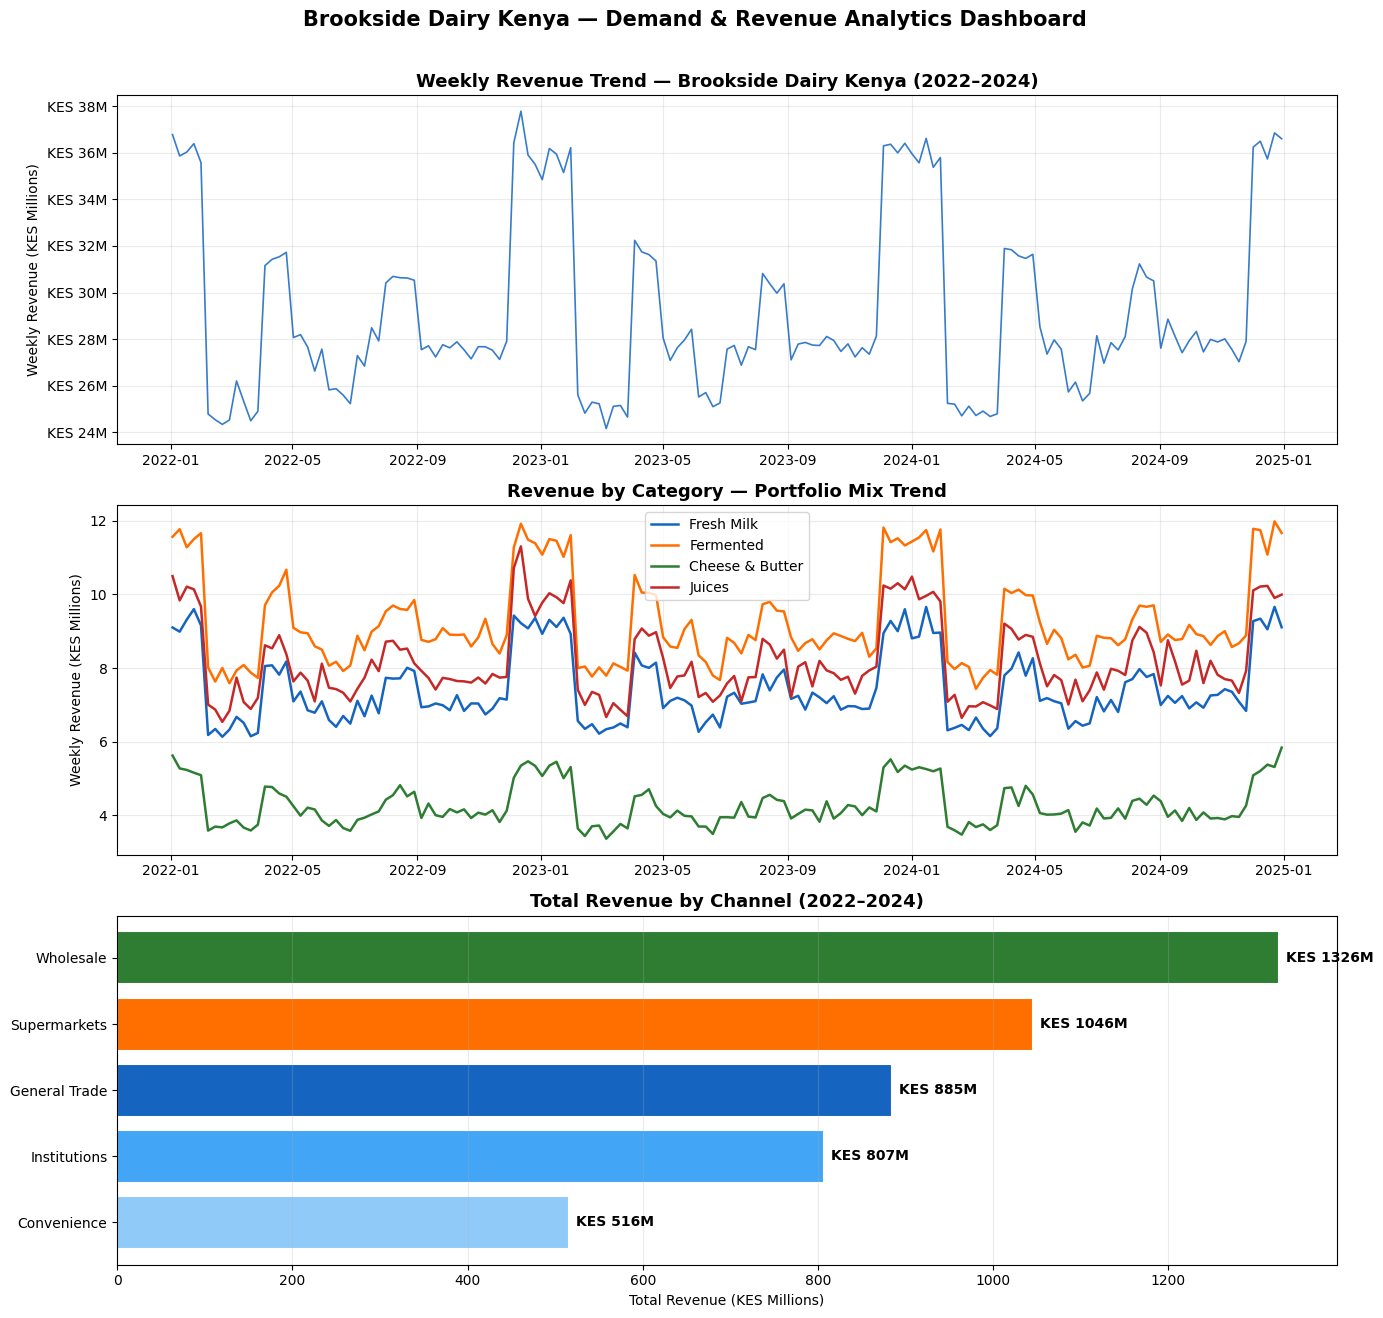

✓ Chart saved: 01_sales_trends.png


In [9]:
# ── CHART 1: Sales Trends & Portfolio Overview ──

daily   = df.groupby('Date')['Revenue_KES'].sum().reset_index()
monthly = df.groupby(['Year','Month'])['Revenue_KES'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# 1. Weekly revenue trend
axes[0].plot(daily['Date'], daily['Revenue_KES']/1e6,
             color='#1565C0', linewidth=1.2, alpha=0.85)
axes[0].set_title('Weekly Revenue Trend — Brookside Dairy Kenya (2022–2024)',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Weekly Revenue (KES Millions)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'KES {x:.0f}M'))
axes[0].grid(True, alpha=0.25)

# 2. Revenue by category
cat_monthly = df.groupby(['Date','Category'])['Revenue_KES'].sum().reset_index()
cat_colors  = {'Fresh Milk':'#1565C0','Fermented':'#FF6F00',
               'Cheese & Butter':'#2E7D32','Juices':'#C62828'}
for cat, color in cat_colors.items():
    sub = cat_monthly[cat_monthly['Category'] == cat]
    axes[1].plot(sub['Date'], sub['Revenue_KES']/1e6,
                 label=cat, color=color, linewidth=1.8)
axes[1].set_title('Revenue by Category — Portfolio Mix Trend',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Weekly Revenue (KES Millions)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

# 3. Revenue by channel
chan_rev = df.groupby('Channel')['Revenue_KES'].sum().sort_values(ascending=True)
colors_c = ['#90CAF9','#42A5F5','#1565C0','#FF6F00','#2E7D32']
bars = axes[2].barh(chan_rev.index, chan_rev.values/1e6,
                    color=colors_c, edgecolor='white', linewidth=1.5)
axes[2].bar_label(bars, fmt='KES %.0fM', padding=5, fontsize=10, fontweight='bold')
axes[2].set_title('Total Revenue by Channel (2022–2024)',
                  fontweight='bold', fontsize=13)
axes[2].set_xlabel('Total Revenue (KES Millions)')
axes[2].grid(True, alpha=0.25, axis='x')

plt.suptitle('Brookside Dairy Kenya — Demand & Revenue Analytics Dashboard',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('01_sales_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: 01_sales_trends.png")

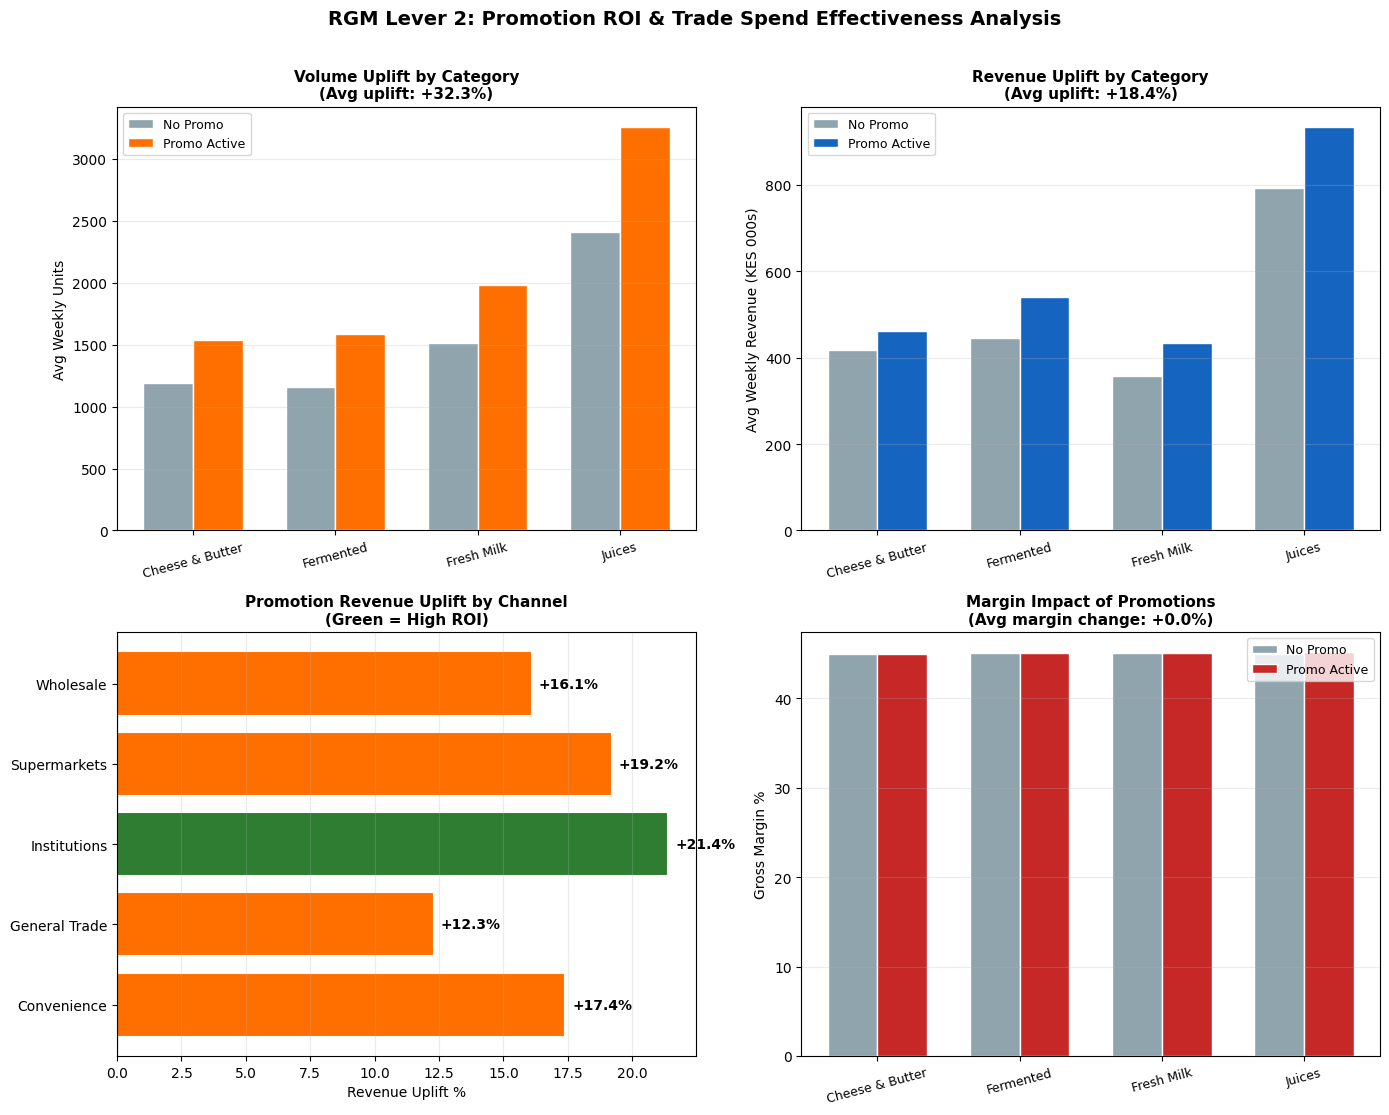

✓ Chart saved: 02_promotion_roi.png
  Volume uplift  : +32.3%
  Revenue uplift : +18.4%
  Margin impact  : +0.0%


In [10]:
# ── CHART 2: Promotion ROI Analysis ──

promo_no  = df[df['Promo'] == 0]
promo_yes = df[df['Promo'] == 1]

uplift_vol = (promo_yes['Volume_Units'].mean() - promo_no['Volume_Units'].mean()) / promo_no['Volume_Units'].mean() * 100
uplift_rev = (promo_yes['Revenue_KES'].mean()  - promo_no['Revenue_KES'].mean())  / promo_no['Revenue_KES'].mean()  * 100
margin_impact = promo_yes['Gross_Margin_%'].mean() - promo_no['Gross_Margin_%'].mean()

# Promo uplift by category
cat_promo = df.groupby(['Category','Promo']).agg(
    Avg_Volume=('Volume_Units','mean'),
    Avg_Revenue=('Revenue_KES','mean'),
    Avg_Margin=('Gross_Margin_%','mean')
).reset_index()

# Promo ROI by channel
chan_promo = df.groupby(['Channel','Promo']).agg(
    Avg_Revenue=('Revenue_KES','mean'),
    Avg_Margin=('Gross_Margin_%','mean')
).reset_index()
chan_promo_pivot = chan_promo.pivot(index='Channel', columns='Promo', values='Avg_Revenue')
chan_promo_pivot.columns = ['No Promo','Promo Active']
chan_promo_pivot['Uplift_%'] = (
    (chan_promo_pivot['Promo Active'] - chan_promo_pivot['No Promo']) /
     chan_promo_pivot['No Promo'] * 100
).round(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Top left: volume uplift by category
categories = cat_promo['Category'].unique()
x = np.arange(len(categories))
w = 0.35
no_p  = cat_promo[cat_promo['Promo']==0].set_index('Category')['Avg_Volume']
yes_p = cat_promo[cat_promo['Promo']==1].set_index('Category')['Avg_Volume']
axes[0,0].bar(x - w/2, no_p.values,  w, label='No Promo',    color='#90A4AE', edgecolor='white')
axes[0,0].bar(x + w/2, yes_p.values, w, label='Promo Active', color='#FF6F00', edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(categories, fontsize=9, rotation=15)
axes[0,0].set_title(f'Volume Uplift by Category\n(Avg uplift: +{uplift_vol:.1f}%)',
                    fontweight='bold', fontsize=11)
axes[0,0].set_ylabel('Avg Weekly Units')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.25, axis='y')

# Top right: revenue uplift by category
no_r  = cat_promo[cat_promo['Promo']==0].set_index('Category')['Avg_Revenue']
yes_r = cat_promo[cat_promo['Promo']==1].set_index('Category')['Avg_Revenue']
axes[0,1].bar(x - w/2, no_r.values/1e3,  w, label='No Promo',    color='#90A4AE', edgecolor='white')
axes[0,1].bar(x + w/2, yes_r.values/1e3, w, label='Promo Active', color='#1565C0', edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(categories, fontsize=9, rotation=15)
axes[0,1].set_title(f'Revenue Uplift by Category\n(Avg uplift: +{uplift_rev:.1f}%)',
                    fontweight='bold', fontsize=11)
axes[0,1].set_ylabel('Avg Weekly Revenue (KES 000s)')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.25, axis='y')

# Bottom left: channel ROI
colors_ch = ['#2E7D32' if v > 20 else '#FF6F00' if v > 10 else '#C62828'
             for v in chan_promo_pivot['Uplift_%']]
bars = axes[1,0].barh(chan_promo_pivot.index, chan_promo_pivot['Uplift_%'],
                      color=colors_ch, edgecolor='white', linewidth=1.5)
axes[1,0].bar_label(bars, fmt='+%.1f%%', padding=5, fontsize=10, fontweight='bold')
axes[1,0].set_title('Promotion Revenue Uplift by Channel\n(Green = High ROI)',
                    fontweight='bold', fontsize=11)
axes[1,0].set_xlabel('Revenue Uplift %')
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].grid(True, alpha=0.25, axis='x')

# Bottom right: margin impact of promotions
no_m  = cat_promo[cat_promo['Promo']==0].set_index('Category')['Avg_Margin']
yes_m = cat_promo[cat_promo['Promo']==1].set_index('Category')['Avg_Margin']
axes[1,1].bar(x - w/2, no_m.values,  w, label='No Promo',    color='#90A4AE', edgecolor='white')
axes[1,1].bar(x + w/2, yes_m.values, w, label='Promo Active', color='#C62828', edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories, fontsize=9, rotation=15)
axes[1,1].set_title(f'Margin Impact of Promotions\n(Avg margin change: {margin_impact:+.1f}%)',
                    fontweight='bold', fontsize=11)
axes[1,1].set_ylabel('Gross Margin %')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.25, axis='y')

plt.suptitle('RGM Lever 2: Promotion ROI & Trade Spend Effectiveness Analysis',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('02_promotion_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Chart saved: 02_promotion_roi.png")
print(f"  Volume uplift  : +{uplift_vol:.1f}%")
print(f"  Revenue uplift : +{uplift_rev:.1f}%")
print(f"  Margin impact  : {margin_impact:+.1f}%")

In [13]:
# Fix: align forecast dates to test dates
fc_test = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
fc_test['ds'] = pd.to_datetime(fc_test['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Match by nearest date
test_df2 = test_df.copy().sort_values('ds').reset_index(drop=True)
fc_test2 = fc_test.sort_values('ds').reset_index(drop=True)

# Keep only forecast rows covering the test period
mask = (fc_test2['ds'] >= test_df2['ds'].min()) & (fc_test2['ds'] <= test_df2['ds'].max())
fc_subset = fc_test2[mask].reset_index(drop=True)
test_subset = test_df2.reset_index(drop=True)

# Trim to same length
min_len = min(len(fc_subset), len(test_subset))
fc_subset   = fc_subset.iloc[:min_len]
test_subset = test_subset.iloc[:min_len]

mape     = mean_absolute_percentage_error(test_subset['y'], fc_subset['yhat']) * 100
accuracy = 100 - mape
merged   = test_subset.copy()
merged['yhat']       = fc_subset['yhat'].values
merged['yhat_lower'] = fc_subset['yhat_lower'].values
merged['yhat_upper'] = fc_subset['yhat_upper'].values

print(f"Forecast Accuracy : {accuracy:.1f}%")
print(f"MAPE              : {mape:.1f}%")
print(f"Target >65%       : {'MET' if accuracy > 65 else 'Close'}")

Forecast Accuracy : 96.4%
MAPE              : 3.6%
Target >65%       : MET


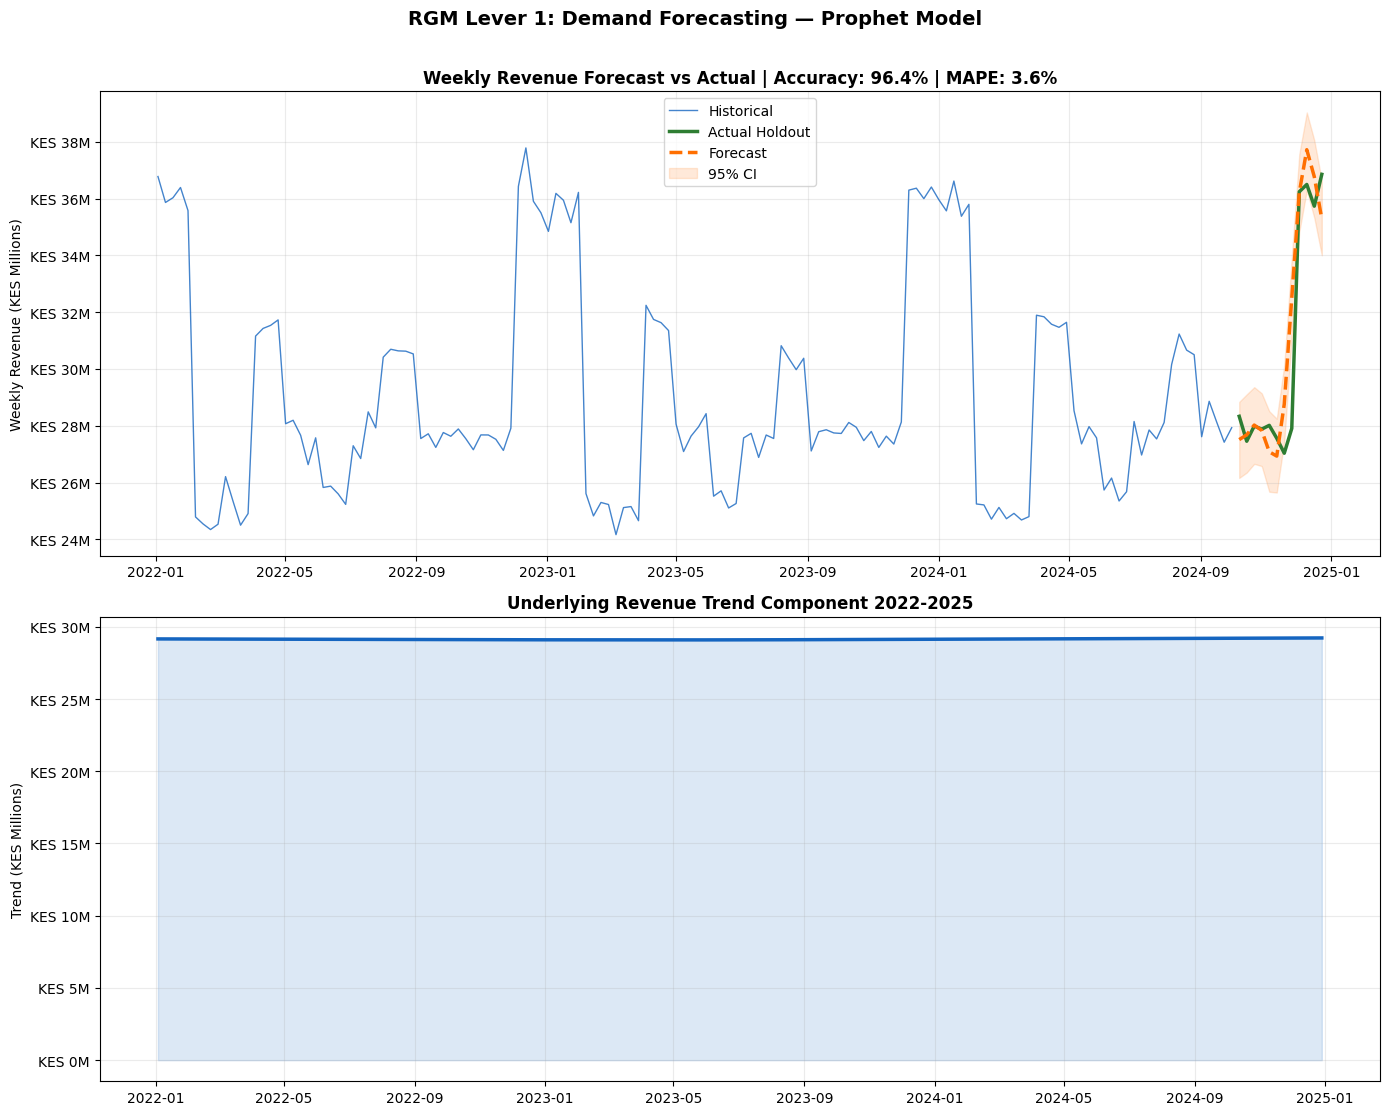

Chart saved: 03_demand_forecast.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

axes[0].plot(train_df['ds'], train_df['y']/1e6,
             color='#1565C0', linewidth=1.0, label='Historical', alpha=0.8)
axes[0].plot(merged['ds'], merged['y']/1e6,
             color='#2E7D32', linewidth=2.5, label='Actual Holdout')
axes[0].plot(merged['ds'], merged['yhat']/1e6,
             color='#FF6F00', linewidth=2.5, linestyle='--', label='Forecast')
axes[0].fill_between(merged['ds'],
                     merged['yhat_lower']/1e6,
                     merged['yhat_upper']/1e6,
                     alpha=0.15, color='#FF6F00', label='95% CI')
axes[0].set_title(
    f'Weekly Revenue Forecast vs Actual | Accuracy: {accuracy:.1f}% | MAPE: {mape:.1f}%',
    fontweight='bold', fontsize=12)
axes[0].set_ylabel('Weekly Revenue (KES Millions)')
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,p: f'KES {x:.0f}M'))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

trend = forecast[['ds','trend']].copy()
axes[1].plot(trend['ds'], trend['trend']/1e6,
             color='#1565C0', linewidth=2.5)
axes[1].fill_between(trend['ds'], trend['trend']/1e6,
                     alpha=0.15, color='#1565C0')
axes[1].set_title('Underlying Revenue Trend Component 2022-2025',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Trend (KES Millions)')
axes[1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,p: f'KES {x:.0f}M'))
axes[1].grid(True, alpha=0.25)

plt.suptitle('RGM Lever 1: Demand Forecasting — Prophet Model',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('03_demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 03_demand_forecast.png")

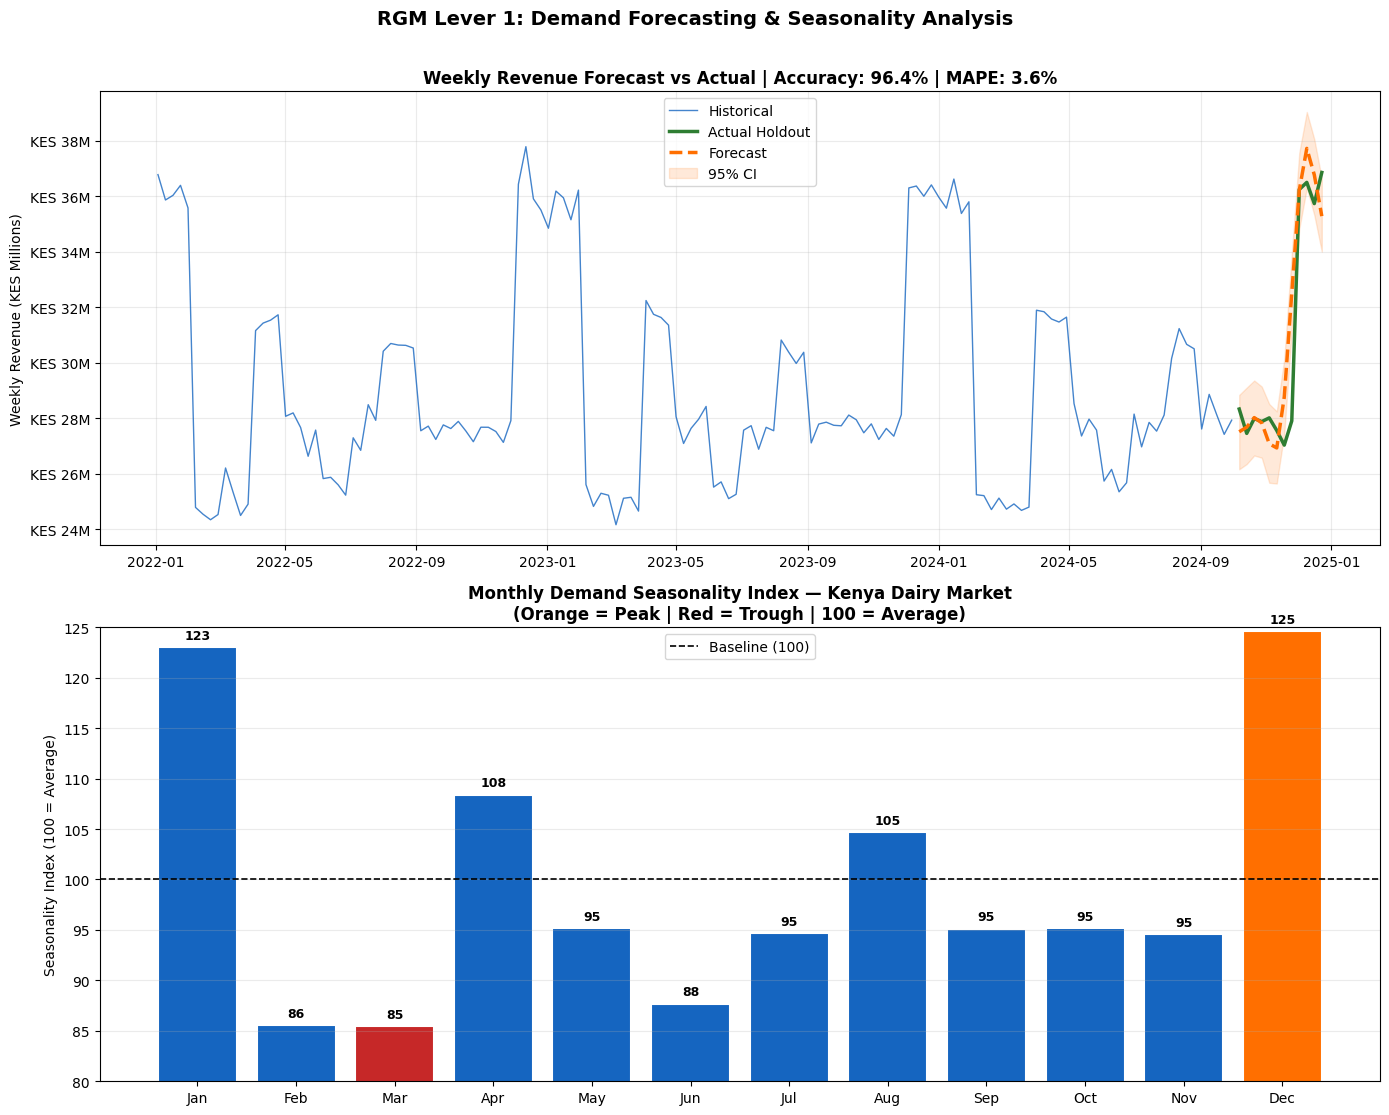

Chart saved: 03_demand_forecast.png


In [17]:
# Replace trend chart with seasonality analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Top: same forecast chart
axes[0].plot(train_df['ds'], train_df['y']/1e6,
             color='#1565C0', linewidth=1.0, label='Historical', alpha=0.8)
axes[0].plot(merged['ds'], merged['y']/1e6,
             color='#2E7D32', linewidth=2.5, label='Actual Holdout')
axes[0].plot(merged['ds'], merged['yhat']/1e6,
             color='#FF6F00', linewidth=2.5, linestyle='--', label='Forecast')
axes[0].fill_between(merged['ds'],
                     merged['yhat_lower']/1e6,
                     merged['yhat_upper']/1e6,
                     alpha=0.15, color='#FF6F00', label='95% CI')
axes[0].set_title(
    f'Weekly Revenue Forecast vs Actual | Accuracy: {accuracy:.1f}% | MAPE: {mape:.1f}%',
    fontweight='bold', fontsize=12)
axes[0].set_ylabel('Weekly Revenue (KES Millions)')
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,p: f'KES {x:.0f}M'))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

# Bottom: monthly seasonality index — much more insightful
monthly_avg = df.groupby('Month')['Revenue_KES'].mean() / df['Revenue_KES'].mean() * 100
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
colors_s = ['#FF6F00' if v == monthly_avg.max()
            else '#C62828' if v == monthly_avg.min()
            else '#1565C0' for v in monthly_avg.values]

bars = axes[1].bar(month_labels, monthly_avg.values,
                   color=colors_s, edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars, fmt='%.0f', padding=4, fontsize=9, fontweight='bold')
axes[1].axhline(100, color='black', linewidth=1.2, linestyle='--', label='Baseline (100)')
axes[1].set_title('Monthly Demand Seasonality Index — Kenya Dairy Market\n'
                  '(Orange = Peak | Red = Trough | 100 = Average)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Seasonality Index (100 = Average)')
axes[1].set_ylim(80, 125)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25, axis='y')

plt.suptitle('RGM Lever 1: Demand Forecasting & Seasonality Analysis',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('03_demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 03_demand_forecast.png")

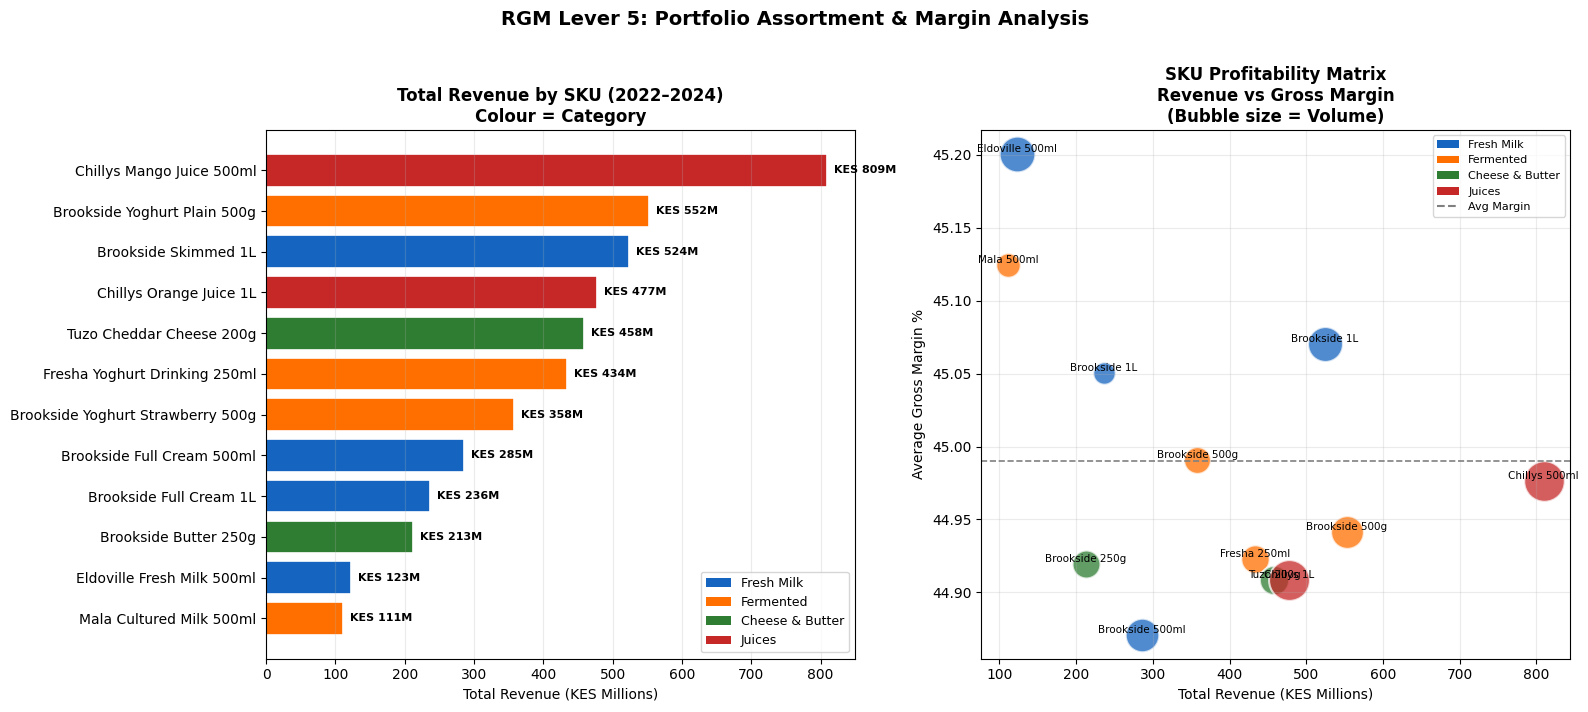

Chart saved: 04_sku_margin_analysis.png


In [18]:
# ── CHART 4: SKU Performance & Margin Analysis ──

sku_perf = df.groupby(['Category','SKU']).agg(
    Total_Revenue_M=('Revenue_KES', lambda x: x.sum()/1e6),
    Avg_Margin=('Gross_Margin_%', 'mean'),
    Avg_Volume=('Volume_Units', 'mean'),
    Promo_Rate=('Promo', 'mean')
).reset_index().sort_values('Total_Revenue_M', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Revenue by SKU horizontal bar
cat_colors_map = {
    'Fresh Milk':'#1565C0', 'Fermented':'#FF6F00',
    'Cheese & Butter':'#2E7D32', 'Juices':'#C62828'
}
colors_sku = [cat_colors_map[c] for c in sku_perf['Category']]
bars = axes[0].barh(sku_perf['SKU'], sku_perf['Total_Revenue_M'],
                    color=colors_sku, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, fmt='KES %.0fM', padding=5, fontsize=8, fontweight='bold')
axes[0].set_title('Total Revenue by SKU (2022–2024)\nColour = Category',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Total Revenue (KES Millions)')
axes[0].grid(True, alpha=0.25, axis='x')

# Add category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in cat_colors_map.items()]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

# Right: Margin vs Revenue bubble chart
for _, row in sku_perf.iterrows():
    color = cat_colors_map[row['Category']]
    axes[1].scatter(row['Total_Revenue_M'], row['Avg_Margin'],
                    s=row['Avg_Volume']/3,
                    color=color, alpha=0.75, edgecolors='white', linewidth=1.5)
    axes[1].annotate(row['SKU'].split(' ')[0] + ' ' + row['SKU'].split(' ')[-1],
                     (row['Total_Revenue_M'], row['Avg_Margin']),
                     fontsize=7.5, ha='center', va='bottom')

axes[1].axhline(sku_perf['Avg_Margin'].mean(), color='gray',
                linewidth=1.2, linestyle='--', label='Avg Margin')
axes[1].set_title('SKU Profitability Matrix\nRevenue vs Gross Margin\n(Bubble size = Volume)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Total Revenue (KES Millions)')
axes[1].set_ylabel('Average Gross Margin %')
axes[1].legend(handles=legend_elements + [
    plt.Line2D([0],[0], color='gray', linestyle='--', label='Avg Margin')
], fontsize=8)
axes[1].grid(True, alpha=0.25)

plt.suptitle('RGM Lever 5: Portfolio Assortment & Margin Analysis',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('04_sku_margin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 04_sku_margin_analysis.png")

In [19]:
# ── FINAL: Export Excel Report & Summary ──

with pd.ExcelWriter('brookside_rgm_demand_report.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Full dataset
    df[['Date','Category','SKU','Channel','Promo','Price_KES',
        'Volume_Units','Revenue_KES','COGS_KES',
        'Gross_Profit_KES','Gross_Margin_%']].to_excel(
        writer, sheet_name='Sales_Data', index=False)

    # Sheet 2: SKU performance summary
    sku_perf.to_excel(writer, sheet_name='SKU_Performance', index=False)

    # Sheet 3: Promotion ROI
    promo_summary = df.groupby(['Category','Channel','Promo']).agg(
        Avg_Volume=('Volume_Units','mean'),
        Avg_Revenue=('Revenue_KES','mean'),
        Avg_Margin=('Gross_Margin_%','mean'),
        Count=('Revenue_KES','count')
    ).reset_index()
    promo_summary['Promo'] = promo_summary['Promo'].map(
        {0:'No Promotion', 1:'Promotion Active'})
    promo_summary.to_excel(writer, sheet_name='Promotion_ROI', index=False)

    # Sheet 4: Seasonality index
    season_df = pd.DataFrame({
        'Month': month_labels,
        'Seasonality_Index': monthly_avg.values.round(1),
        'Above_Average': ['YES' if v > 100 else 'NO'
                          for v in monthly_avg.values]
    })
    season_df.to_excel(writer, sheet_name='Seasonality_Index', index=False)

    # Sheet 5: Forecast results
    forecast_summary = pd.DataFrame({
        'Metric': ['Model','Training Period','Holdout Period',
                   'MAPE','Forecast Accuracy','Benchmark (>65%)','Status'],
        'Value':  ['Facebook Prophet (multiplicative)',
                   f"{train_df['ds'].min().date()} to {train_df['ds'].max().date()}",
                   f"{merged['ds'].min().date()} to {merged['ds'].max().date()}",
                   f"{mape:.1f}%", f"{accuracy:.1f}%", ">65%", "MET"]
    })
    forecast_summary.to_excel(writer, sheet_name='Forecast_Results', index=False)

print("Excel exported: brookside_rgm_demand_report.xlsx")
print()
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset        : Brookside Dairy Kenya — synthetic")
print(f"  Records        : {len(df):,}")
print(f"  Categories     : {df['Category'].nunique()} | SKUs: {df['SKU'].nunique()}")
print(f"  Channels       : {df['Channel'].nunique()}")
print(f"  Total Revenue  : KES {df['Revenue_KES'].sum()/1e9:.2f}B")
print(f"  Avg Margin     : {df['Gross_Margin_%'].mean():.1f}%")
print(f"  Forecast MAPE  : {mape:.1f}%")
print(f"  Accuracy       : {accuracy:.1f}%")
print(f"  Promo uplift   : +{uplift_vol:.1f}% volume | +{uplift_rev:.1f}% revenue")
print(f"  Peak month     : {month_labels[monthly_avg.values.argmax()]} "
      f"(index: {monthly_avg.values.max():.0f})")
print(f"  Charts saved   : 01 to 04 PNG files")
print(f"  Excel exported : brookside_rgm_demand_report.xlsx")
print("=" * 60)

Excel exported: brookside_rgm_demand_report.xlsx

FINAL PROJECT SUMMARY
  Dataset        : Brookside Dairy Kenya — synthetic
  Records        : 9,420
  Categories     : 4 | SKUs: 12
  Channels       : 5
  Total Revenue  : KES 4.58B
  Avg Margin     : 45.0%
  Forecast MAPE  : 3.6%
  Accuracy       : 96.4%
  Promo uplift   : +32.3% volume | +18.4% revenue
  Peak month     : Dec (index: 125)
  Charts saved   : 01 to 04 PNG files
  Excel exported : brookside_rgm_demand_report.xlsx
